In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
df = yf.download(tickers=['AAPL'],period='1mo',interval='5m');

[*********************100%***********************]  1 of 1 completed


In [3]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,
2026-04-30 13:30:00+00:00,269.035004,270.910004,268.750000,270.500000,2367257
2026-04-30 13:35:00+00:00,268.829987,269.114990,268.140015,268.829987,988268
2026-04-30 13:40:00+00:00,269.070007,269.410004,268.619995,268.825012,559369
2026-04-30 13:45:00+00:00,269.468414,270.059906,269.040009,269.070007,569624
2026-04-30 13:50:00+00:00,270.588013,270.709991,269.420013,269.456787,601865
...,...,...,...,...,...
2026-05-29 19:35:00+00:00,311.890015,311.989990,311.570496,311.720001,397472
2026-05-29 19:40:00+00:00,311.739990,311.950012,311.649994,311.885010,377567


In [4]:
n = 10
df['ROC'] = (df['Close'] - df['Close'].shift(n)) / df['Close'].shift(n) * 100

A. Rate of Change (ROC)

Simple momentum.

ROC= ((Closeₜ - close(ₜ-n))/close(ₜ-n)) x 100

Positive → bullish momentum

Negative → bearish momentum

In [5]:
df['ROC']

Datetime
2026-04-30 13:30:00+00:00         NaN
2026-04-30 13:35:00+00:00         NaN
2026-04-30 13:40:00+00:00         NaN
2026-04-30 13:45:00+00:00         NaN
2026-04-30 13:50:00+00:00         NaN
                               ...   
2026-05-29 19:35:00+00:00    0.467083
2026-05-29 19:40:00+00:00    0.389683
2026-05-29 19:45:00+00:00    0.368671
2026-05-29 19:50:00+00:00    0.564217
2026-05-29 19:55:00+00:00    0.276346
Name: ROC, Length: 1638, dtype: float64

In [6]:
max_roc = df['ROC'].max()
min_roc = df['ROC'].min()
print(f"Maximum ROC: {max_roc}")
print(f"Minimum ROC: {min_roc}")

Maximum ROC: 5.207107033303479
Minimum ROC: -1.8449516599751303


In [7]:
df.describe()

Price,Close,High,Low,Open,Volume,ROC
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
count,1638.000000,1638.000000,1638.000000,1638.000000,1.638000e+03,1628.000000
mean,296.079098,296.346114,295.787127,296.059891,4.737438e+05,0.089131
std,11.321525,11.300093,11.347531,11.321347,7.692058e+05,0.533017
min,268.829987,269.114990,268.140015,268.825012,0.000000e+00,-1.844952
25%,288.292526,288.769997,288.102509,288.435020,2.311222e+05,-0.189397
50%,297.434998,297.747498,297.120010,297.410004,3.169470e+05,0.046258
75%,304.609985,304.737427,304.459999,304.610077,4.779430e+05,0.280015
max,314.351105,315.000000,313.720001,314.399994,1.631315e+07,5.207107


In [8]:
df.isnull().sum()

Price   Ticker
Close   AAPL       0
High    AAPL       0
Low     AAPL       0
Open    AAPL       0
Volume  AAPL       0
ROC               10
dtype: int64

In [9]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL'),
            (   'ROC',     '')],
           names=['Price', 'Ticker'])

In [10]:
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

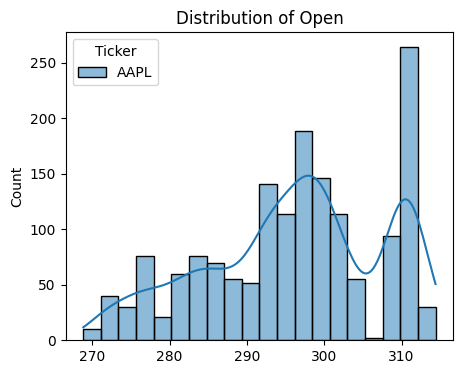

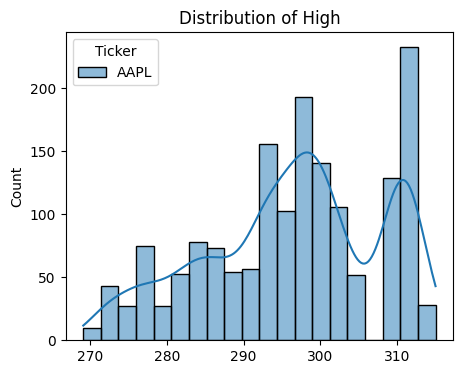

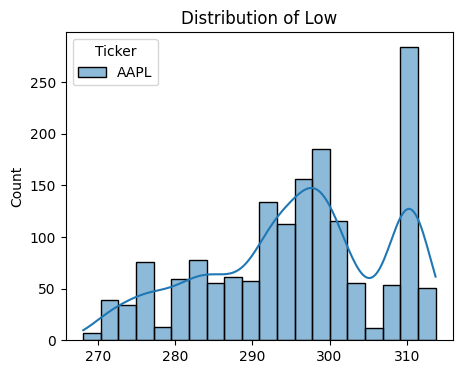

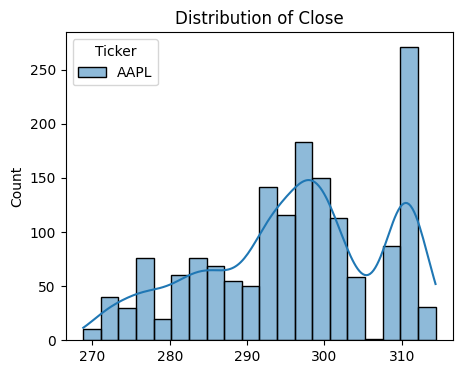

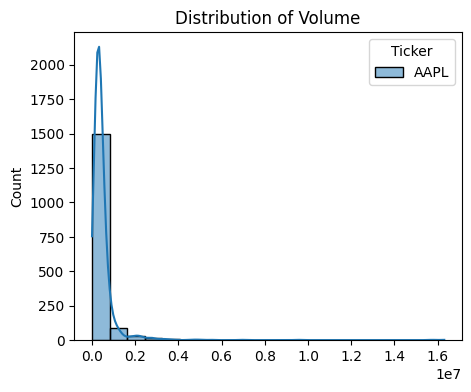

In [11]:
for col in numeric_columns:
  plt.figure(figsize=(5, 4))
  sns.histplot(df[col], kde=True, bins=20)
  #kde -> kernel density estimation
  plt.title(f'Distribution of {col}')
  plt.show()


In [12]:
df.columns = [col[0] if col[1]=='' else f'{col[0]}_{col[1]}' for col in df.columns]

print(df.columns)

Index(['Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL', 'Volume_AAPL',
       'ROC'],
      dtype='str')


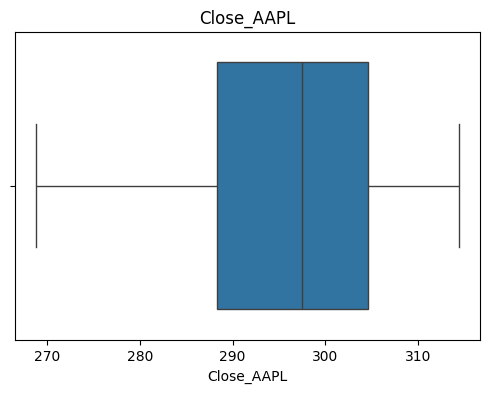

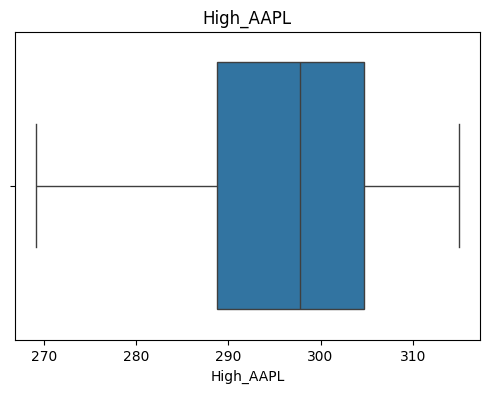

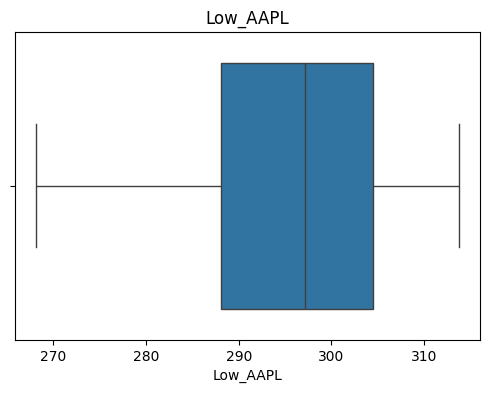

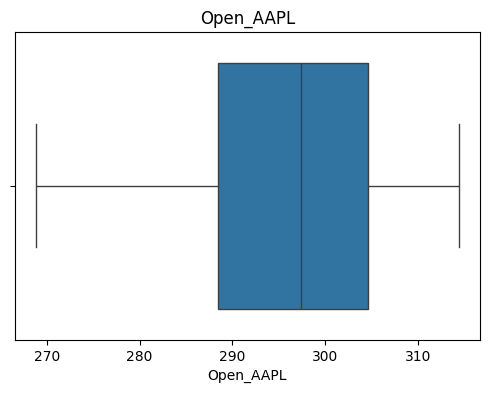

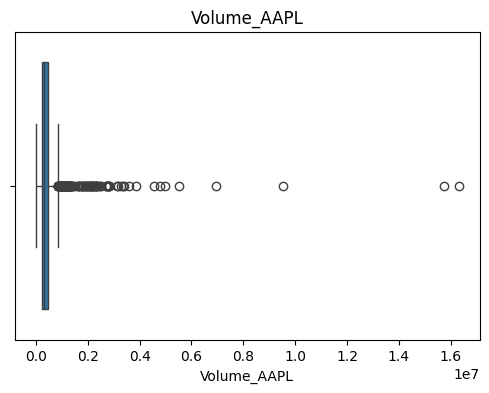

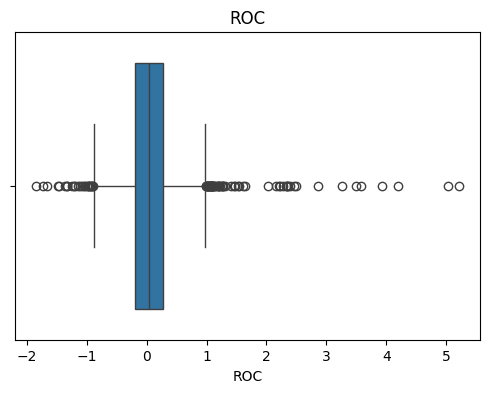

In [13]:
numeric_columns = df.select_dtypes(include='number').columns

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col].dropna())
    plt.title(col)
    plt.show()

<Axes: >

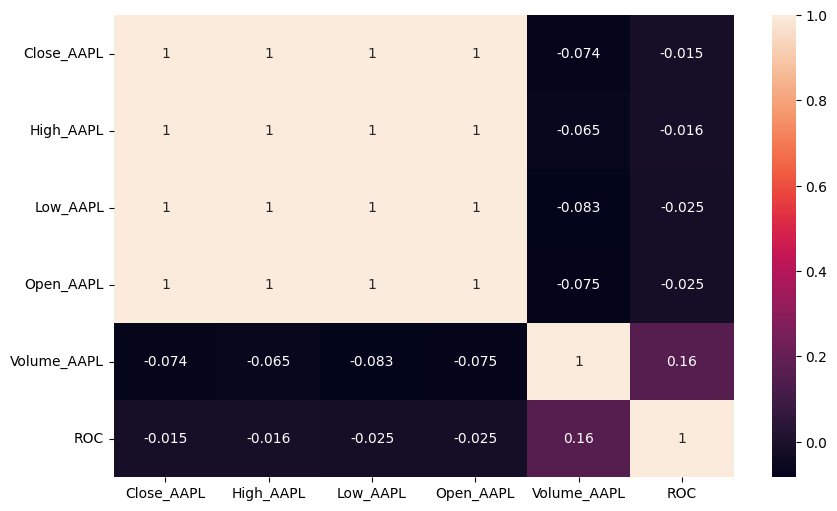

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/workspaces/algo-trading/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/workspaces/algo-trading/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 348, in dispatch_control
    await self.process_control(msg)
  File "/workspaces/algo-trading/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 354, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/workspaces/algo-trading/.venv/lib/python3.12/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/workspaces/algo-trading/.venv/lib/python3.12/site-packages/zmq/

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

DATA CLEANING AND PREPROCESSING

In [16]:
df_cleaned = df.copy()

In [17]:
df_cleaned.head()

,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL,ROC
Datetime,,,,,,
2026-04-30 13:30:00+00:00,269.035004,270.910004,268.750000,270.500000,2367257,NaN
2026-04-30 13:35:00+00:00,268.829987,269.114990,268.140015,268.829987,988268,NaN
2026-04-30 13:40:00+00:00,269.070007,269.410004,268.619995,268.825012,559369,NaN
2026-04-30 13:45:00+00:00,269.468414,270.059906,269.040009,269.070007,569624,NaN
2026-04-30 13:50:00+00:00,270.588013,270.709991,269.420013,269.456787,601865,NaN


In [18]:
df_cleaned.shape

(1638, 6)

In [21]:
df_cleaned.drop_duplicates(inplace=True)
#or
df2 = df_cleaned.drop_duplicates()

In [20]:
df_cleaned.shape

(1638, 6)

In [23]:
df_cleaned.isnull().sum()

Close_AAPL      0
High_AAPL       0
Low_AAPL        0
Open_AAPL       0
Volume_AAPL     0
ROC            10
dtype: int64

In [24]:
df_cleaned.dtypes

Close_AAPL     float64
High_AAPL      float64
Low_AAPL       float64
Open_AAPL      float64
Volume_AAPL      int64
ROC            float64
dtype: object

LEBEL ENCODING 
it is used to change object into integer. 
EX- male and female -> 1 and 0

df_cleaned['sex'].value_counts()

df_cleaned['sex'] = df_cleaned['sex'].map({"male":1, "female":0})

df_cleaned.rename(columns={
    'sex' : 'is_male'
},inplace = True)

ONE-HOT ENCODING
It is used to change object having more than two value into integer.
EX- northeast, northwest, southeast, southwest

df_cleaned['region'].value_counts()

df_cleaned = pd.get_dummies(df_cleaned,columns = ['region'], drop_first = True)

In [ ]:
df_cleaned = df_cleaned.astype(int)